# 01 — Data Validation

**Stage 1 of the experiment plan (planning doc Section 7).** Everything downstream — chunking, retrieval, classification — depends on the ContractNLI dataset being clean and the splits being leakage-free. This notebook runs experiments **A01–A07** (Section 8) and records the go/no-go decision before any pipeline code is built on top of this data.

The check logic lives in `scripts/validate_dataset.py` (the reusable, testable module) — this notebook **imports** it, runs it, and adds the exploratory visuals and narrative reasoning that the JSON report alone doesn't carry. This follows the project's notebooks-vs-pipeline rule: notebooks are for deciding, modules are for doing (see `CLAUDE.md`, Section 0A).

In [ ]:
import os
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from pipeline.config import settings
from pipeline.parser import load_all_splits
from scripts.validate_dataset import (
    a01_schema_validation,
    a02_missing_corrupt,
    a03_duplicate_detection,
    a04_leakage_test,
    a05_label_distribution,
    a06_evidence_span_validation,
    a07_token_length_analysis,
)

data_dir = settings.data_path
splits = load_all_splits(data_dir)
print({name: ds.num_documents for name, ds in splits.items()})

{'train': 423, 'dev': 61, 'test': 123}


In [ ]:
from pipeline.viz_style import CATEGORICAL, SEQUENTIAL_HUE, INK_PRIMARY, INK_MUTED, SURFACE
from pipeline.viz_style import apply_style, style_axes, savefig_kwargs

apply_style()

## A01 — Schema validation

Hypothesis: >99% of the 607 NDAs parse correctly. Go/no-go: if >5% of documents are corrupt, investigate before proceeding.

In [ ]:
a01 = a01_schema_validation(data_dir, splits)
a01

{'train': {'raw_count': 423, 'parsed_count': 423},
 'dev': {'raw_count': 61, 'parsed_count': 61},
 'test': {'raw_count': 123, 'parsed_count': 123},
 'total_raw': 607,
 'total_parsed': 607,
 'parse_success_rate': 1.0,
 'pass': True}

## A02 — Missing / corrupt data

Hypothesis: <1% of documents are corrupt (empty text or zero annotations).

In [ ]:
a02 = a02_missing_corrupt(splits)
a02

{'train': {'empty_text': 0, 'no_annotations': 0},
 'dev': {'empty_text': 0, 'no_annotations': 0},
 'test': {'empty_text': 0, 'no_annotations': 0},
 'total_docs': 607,
 'total_corrupt': 0,
 'corrupt_rate': 0.0,
 'pass': True}

## A03 — Duplicate / near-duplicate detection

Hypothesis: <2% duplicates (exact text-hash match).

In [ ]:
a03 = a03_duplicate_detection(splits)
a03

{'total_docs': 607,
 'duplicate_groups': 1,
 'duplicate_doc_count': 2,
 'duplicate_rate': 0.0033,
 'example_groups': [['test/52', 'test/97']],
 'pass': True}

## A04 — NDA-level leakage test

Hypothesis: zero document overlap between train/dev/test. This is the split-safety gate — if it fails, we must re-split at the document level before doing anything else.

In [ ]:
a04 = a04_leakage_test(splits)
a04

{'leaked_doc_count': 0, 'leaked_doc_ids': [], 'pass': True}

## A05 — Label distribution

This feeds directly into the majority-class baseline (T013) and stratification decisions.

In [ ]:
a05 = a05_label_distribution(splits)
a05["overall"], a05["overall_proportions"]

({'Entailment': 5017, 'Contradiction': 1156, 'NotMentioned': 4146},
 {'Entailment': 0.4862, 'Contradiction': 0.112, 'NotMentioned': 0.4018})

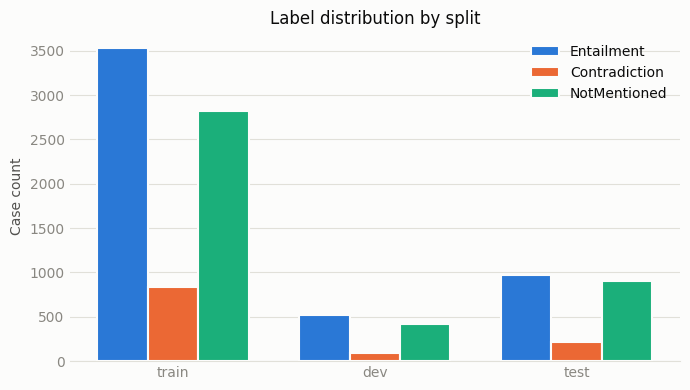

In [ ]:
labels = ["Entailment", "Contradiction", "NotMentioned"]
split_names = [s for s in ("train", "dev", "test") if s in a05]

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(split_names))
width = 0.25
for i, label in enumerate(labels):
    values = [a05[split][label] for split in split_names]
    ax.bar(
        [xi + i * width for xi in x], values, width,
        label=label, color=CATEGORICAL[label],
        edgecolor=SURFACE, linewidth=1.5, zorder=3,
    )
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(split_names)
ax.set_ylabel("Case count")
ax.set_title("Label distribution by split")
style_axes(ax)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("results/comparisons/label_distribution.png", **savefig_kwargs())
plt.show()

**Finding — corrects a planning-doc assumption:** Section 8 (A05) hypothesized *"NotMentioned is majority."* The actual overall distribution is **Entailment 48.6% / NotMentioned 40.2% / Contradiction 11.2%** — Entailment is the true majority class. This means:

- The majority-class baseline (T013/B01) should always predict **Entailment**, not NotMentioned.
- Contradiction is the minority class (~11%) and will need close attention in macro-F1 and risk-sensitive recall, since it's cheapest for a weak model to get wrong.

## A06 — Evidence span validation

Hypothesis: >99% of gold evidence spans are valid text ranges (`0 <= start < end <= len(text)`).

In [ ]:
a06 = a06_evidence_span_validation(splits)
a06

{'total_spans': 48058,
 'invalid_spans': 0,
 'invalid_rate': 0.0,
 'examples': [],
 'pass': True}

## A07 — Document token-length analysis

Hypothesis: median ~3K tokens, some documents >8K. This determines whether full-context baselines are even feasible and informs chunk-size choices for retrieval.

In [ ]:
a07 = a07_token_length_analysis(splits)
a07["overall"]

{'min': 272, 'max': 11340, 'mean': 2145.9, 'median': 1901, 'p95': 4632}

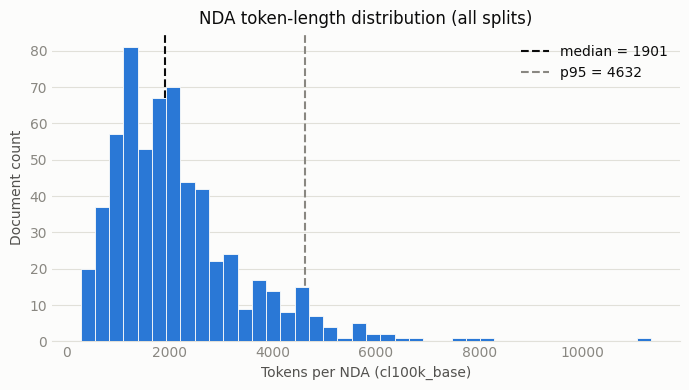

In [ ]:
import tiktoken

encoding = tiktoken.get_encoding("cl100k_base")
all_lengths = []
for ds in splits.values():
    all_lengths.extend(len(encoding.encode(doc.text)) for doc in ds.documents)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(all_lengths, bins=40, color=SEQUENTIAL_HUE, edgecolor=SURFACE, linewidth=0.6, zorder=3)
ax.axvline(a07["overall"]["median"], color=INK_PRIMARY, linestyle="--", linewidth=1.5,
           label=f'median = {a07["overall"]["median"]}')
ax.axvline(a07["overall"]["p95"], color=INK_MUTED, linestyle="--", linewidth=1.5,
           label=f'p95 = {a07["overall"]["p95"]}')
ax.set_xlabel("Tokens per NDA (cl100k_base)")
ax.set_ylabel("Document count")
ax.set_title("NDA token-length distribution (all splits)")
style_axes(ax)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("results/comparisons/token_length_distribution.png", **savefig_kwargs())
plt.show()

**Finding:** median document length is ~1,900 tokens (lower than the doc's ~3K estimate), but the tail is long — p95 is ~4,600 tokens and the longest document is 11,340 tokens. A handful of documents exceed what fits comfortably alongside a system prompt + hypothesis + JSON schema instructions in a full-context baseline, which is exactly the case retrieval is meant to handle. This supports building the full-context baseline (B03) as a genuine “throw everything at the model” test for typical documents, while expecting it to degrade on the long tail.

## Go / No-Go Decision

| Check | Result | Gate |
|---|---|---|
| A01 Schema validation | 607/607 parse (100%) | PASS |
| A02 Missing/corrupt | 0% corrupt | PASS |
| A03 Duplicates | 0.33% (2 docs, 1 pair) | PASS (<2%) |
| A04 Split leakage | 0 overlapping docs | PASS |
| A05 Label distribution | Entailment 48.6% / NotMentioned 40.2% / Contradiction 11.2% | Informational — corrects majority-class assumption |
| A06 Evidence span validity | 0 invalid / 48,058 spans | PASS |
| A07 Token length | median 1,901, p95 4,632, max 11,340 | Informational — confirms retrieval is needed for long-tail docs |

**Decision: PROCEED.** The dataset is clean and the splits are leakage-safe. No re-splitting or data cleaning is required. Move to Phase 2 (evaluation harness, T007) with one correction carried forward: the majority-class baseline must predict **Entailment**, not NotMentioned.